# Stage 3: Conditional Latent Diffusion Model (LDM) for Hand OA Synthesis

**Project:** KL 3/4 Hand Osteoarthritis Image Generation  
**Author:** Maria Martin  
  

---

## Overview

This notebook implements a **KL-grade-conditioned Latent Diffusion Model (LDM)** to generate synthetic DIP joint X-ray images, targeting the underrepresented KL 3 and KL 4 severity classes.

### Architecture Summary
```
Input image (180×180, grayscale)
       │
   [VAE Encoder]  ──── trained first, then frozen
       │
  Latent z (8×8×8)
       │
   [UNet + KL Embedding]  ◄── KL grade label (0–4)
       │  (denoises in latent space)
   [DDPM Schedule]
       │
   [VAE Decoder]
       │
  Generated image (64×64)
```

### Notebook Structure
1. Setup & Drive mount  
2. Dataset class (from `manifest_dip_only.csv`)  
3. VAE — train & save  
4. UNet denoiser with KL conditioning  
5. DDPM noise schedule  
6. LDM training loop  
7. Image generation & visualisation  


## Cell 1 — Mount Google Drive

In [ ]:
# Cell 1: This cell mounts Google Drive and sets the 2 key paths

from google.colab import drive
drive.mount('/content/drive')


# PATH
# DRIVE_PROJECT_DIR is the only path you need to run this entire notebook,
# adjust it to wherever the CV-Project folder is located in your Drive

DRIVE_PROJECT_DIR = '/content/drive/MyDrive/CV-Project'
LOCAL_IMG_DIR = '/content/finger_joints_images'

import os
print('Drive mounted. Project dir exists:', os.path.isdir(DRIVE_PROJECT_DIR))
print('Image dir exists:', os.path.isdir(LOCAL_IMG_DIR))

# Extract images from the orginal Finger_Joints dataset
import zipfile, os

zip_path = '/content/drive/MyDrive/CV-Project/data/raw/Finger_Joints.zip'

if not os.path.isdir(LOCAL_IMG_DIR):
    print('Extracting images... (this may take a few minutes)')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(LOCAL_IMG_DIR)
    print('Done!')
else:
    print('Images already extracted.')


# Confirm path has been created and images are ready
import os
path = '/content/finger_joints_images/Finger Joints'
if os.path.isdir(path):
    print(f'Found {len(os.listdir(path))} images — ready!')
else:
    print('Something went wrong — folder not found.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project dir exists: True
Image dir exists: True
Images already extracted.
Found 41060 images — ready!


## Cell 2 — Install Dependencies

In [ ]:
# Cell 2: Install required libraries and confirm GPU is available
# Install einops for attention layers
!pip install einops -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from einops import rearrange
from tqdm import tqdm
import math, os, random

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Cell 3 — Configuration

All hyperparameters are centralised here.

In [ ]:
# Cell 3: Hyperparameters and paths — Stage 3: 180×180

DRIVE_PROJECT_DIR = '/content/drive/MyDrive/CV-Project'
LOCAL_IMG_DIR     = '/content/finger_joints_images'

MANIFEST_PATH  = os.path.join(DRIVE_PROJECT_DIR, 'data', 'splits', 'manifest_dip_only.csv')
VAE_CKPT_PATH  = os.path.join(DRIVE_PROJECT_DIR, 'vae_checkpoint_180.pth')
LDM_CKPT_PATH  = os.path.join(DRIVE_PROJECT_DIR, 'ldm_checkpoint_180.pth')
OUTPUT_DIR     = os.path.join(DRIVE_PROJECT_DIR, 'generated_images')
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(MANIFEST_PATH):
    MANIFEST_PATH = os.path.join(DRIVE_PROJECT_DIR, 'manifest_dip_only.csv')
    print(f'[INFO] Using fallback manifest path: {MANIFEST_PATH}')

GENERATION_SEED = 42

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(GENERATION_SEED)
print(f'Seed set to {GENERATION_SEED}')

# ── Image & latent dimensions ──────────────────────────────────────────────────
IMG_SIZE       = 180          # ← Stage 3: full resolution
LATENT_CH      = 8
LATENT_SIZE    = 22           # ← 180→90→45→22  (3 stride-2 downsamples)

# ── Dataset ───────────────────────────────────────────────────────────────────
IMG_MEAN       = 0.2339
IMG_STD        = 0.2349
NUM_KL_CLASSES = 5

# ── VAE training ──────────────────────────────────────────────────────────────
VAE_BASE_CH      = 48
VAE_EPOCHS       = 50
VAE_BATCH_SIZE   = 16
VAE_LR           = 1e-4
VAE_KLD_WEIGHT   = 0.003
GRAD_LOSS_WEIGHT = 0.25

# ── LDM ───────────────────────────────────────────────────────────────────────
UNET_BASE_CH   = 96
T_STEPS        = 1000
BETA_START     = 1e-4
BETA_END       = 0.02
LDM_EPOCHS     = 150
LDM_LR         = 2e-4
LDM_BATCH_SIZE = 16

# ── Generation ────────────────────────────────────────────────────────────────
GUIDANCE_SCALE = 5.0

print('Configuration loaded. — Stage 3: 180×180')
print(f'  Manifest:   {MANIFEST_PATH}')
print(f'  Image dir:  {LOCAL_IMG_DIR}')
print(f'  Image: {IMG_SIZE}×{IMG_SIZE} → Latent: {LATENT_SIZE}×{LATENT_SIZE}×{LATENT_CH}')
print(f'  UNet base_ch: {UNET_BASE_CH}  |  LDM epochs: {LDM_EPOCHS}')
print(f'  VAE ckpt: {VAE_CKPT_PATH}')
print(f'  LDM ckpt: {LDM_CKPT_PATH}')

Seed set to 42
Configuration loaded. — Stage 3: 180×180
  Manifest:   /content/drive/MyDrive/CV-Project/data/splits/manifest_dip_only.csv
  Image dir:  /content/finger_joints_images
  Image: 180×180 → Latent: 22×22×8
  UNet base_ch: 96  |  LDM epochs: 150
  VAE ckpt: /content/drive/MyDrive/CV-Project/vae_checkpoint_180.pth
  LDM ckpt: /content/drive/MyDrive/CV-Project/ldm_checkpoint_180.pth


## Cell 4 — Dataset Class

Reads from `manifest_dip_only.csv`. Each sample returns an image tensor and its KL grade as an integer label.

In [ ]:
# Cell 4: Load manifest_dip_only.csv, filter by split, apply transforms and
# build dataloaders

class DIPJointDataset(Dataset):
    def __init__(self, manifest_path, split='train', img_root=None,
                 transform=None, kl_grades=None, kl_col='v00_KL'):
        df = pd.read_csv(manifest_path)
        df = df[df['split'] == split].copy()
        df = df.rename(columns={kl_col: 'KL'})
        df = df.dropna(subset=['image_path', 'KL'])
        df = df[df['KL'].astype(str) != '']
        df['KL'] = df['KL'].astype(float).astype(int)

        if kl_grades is not None:
            df = df[df['KL'].isin(kl_grades)]

        self.records   = df.reset_index(drop=True)
        self.img_root  = img_root
        self.transform = transform

        print(f'[{split}] Loaded {len(self.records)} images')
        print(f'  KL distribution: {dict(self.records["KL"].value_counts().sort_index())}')

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        img_path = row['image_path']

        if not os.path.exists(img_path) and self.img_root:
            filename = os.path.basename(img_path)
            img_path = os.path.join(self.img_root, 'Finger Joints', filename)

        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)

        kl_label = int(row['KL'])
        return img, kl_label


# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    # removed RandomAffine — at 64×64, 5° rotation distorts bone anatomy
    # and teaches the model to generate tilted joints
    transforms.ToTensor(),
    transforms.Normalize([IMG_MEAN], [IMG_STD]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([IMG_MEAN], [IMG_STD]),
])

# ── Build datasets ─────────────────────────────────────────────────────────────
train_ds = DIPJointDataset(MANIFEST_PATH, split='train', transform=train_transform)
val_ds   = DIPJointDataset(MANIFEST_PATH, split='val',   transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=VAE_BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=VAE_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs, labels = next(iter(train_loader))
print(f'\nBatch shape: {imgs.shape}  |  Labels: {labels[:8].tolist()}')

[train] Loaded 9199 images
  KL distribution: {0: np.int64(5947), 1: np.int64(1220), 2: np.int64(1770), 3: np.int64(144), 4: np.int64(118)}
[val] Loaded 1993 images
  KL distribution: {0: np.int64(1269), 1: np.int64(288), 2: np.int64(382), 3: np.int64(29), 4: np.int64(25)}

Batch shape: torch.Size([16, 1, 180, 180])  |  Labels: [0, 0, 0, 1, 0, 1, 0, 0]


## Cell 5 — Visualise Sample Images

Sanity check: make sure images load correctly before training anything.

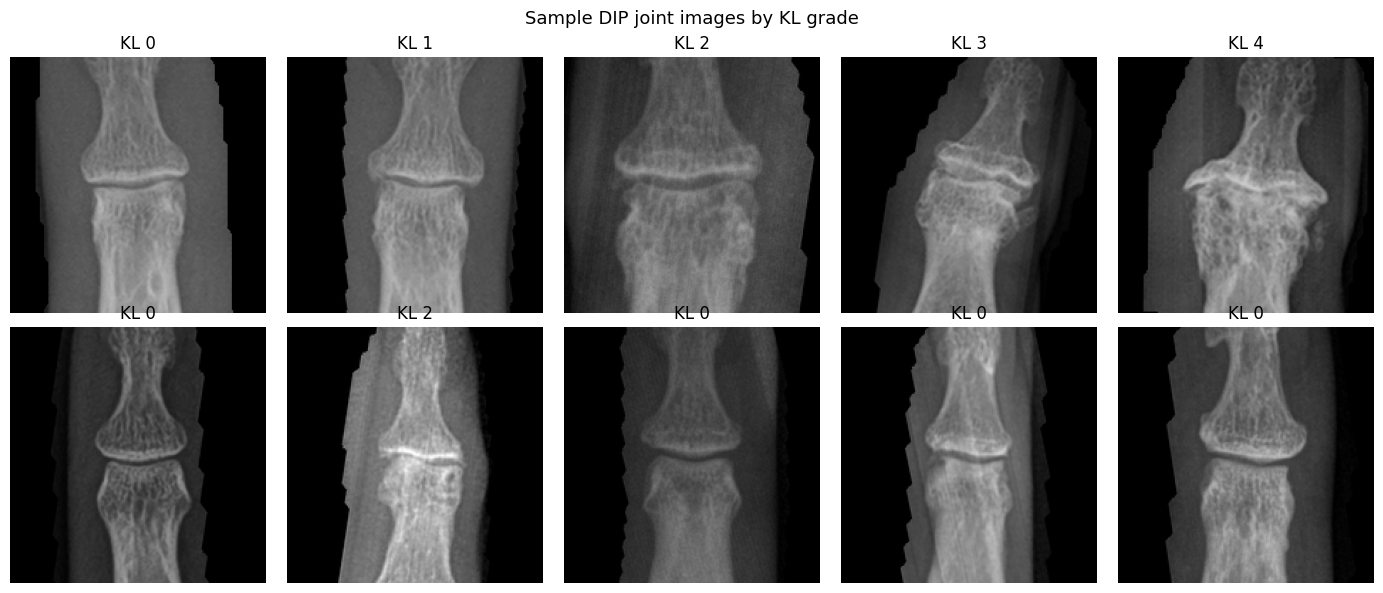

Saved to /content/drive/MyDrive/CV-Project/generated_images


In [ ]:
# Cell 5: Sanity check, display sample images per KL grade before training
def denorm(tensor):
    """Reverse the normalisation for display."""
    return tensor * IMG_STD + IMG_MEAN

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample DIP joint images by KL grade', fontsize=13)

for kl in range(5):
    # Find an example of this KL grade
    mask = train_ds.records['KL'] == kl
    if not mask.any():
        continue
    idx = train_ds.records[mask].index[0]
    img, label = train_ds[idx]
    axes[0][kl].imshow(denorm(img).squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0][kl].set_title(f'KL {label}')
    axes[0][kl].axis('off')

# Second row: random samples
rand_idx = random.sample(range(len(train_ds)), 5)
for i, idx in enumerate(rand_idx):
    img, label = train_ds[idx]
    axes[1][i].imshow(denorm(img).squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1][i].set_title(f'KL {label}')
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=120)
plt.show()
print('Saved to', OUTPUT_DIR)

## Cell 6 — VAE Architecture

The VAE compresses 64×64 images into a compact 8×8×4 latent space. The LDM will learn to denoise in this latent space — much cheaper than operating directly on pixels.

- **Encoder:** Conv → downsample ×3 → output `(batch, 8, 8, 8)` → split into μ and log σ²
- **Decoder:** Upsample ×3 → Conv → output `(batch, 1, 64, 64)`
- **Loss:** Reconstruction (MSE) + KL divergence

In [ ]:
# Cell 6: VAE Architecture

class ResBlock(nn.Module):
    """Residual block used in both encoder and decoder."""
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.GroupNorm(8, ch),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.GroupNorm(8, ch),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x)


class SelfAttentionVAE(nn.Module):
    """
    Self-attention block inside nn.Sequential (B,C,H,W → B,C,H,W).
    At 180×180: placed at the 22×22 bottleneck after 3 downsamples.
    """
    def __init__(self, ch, n_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.attn = nn.MultiheadAttention(ch, n_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        h = h.view(B, C, H * W).permute(0, 2, 1)   # B, HW, C
        h, _ = self.attn(h, h, h)
        h = h.permute(0, 2, 1).view(B, C, H, W)
        return x + h


class VAEEncoder(nn.Module):
    def __init__(self, in_ch=1, base_ch=VAE_BASE_CH, latent_ch=LATENT_CH):
        super().__init__()
        # 180 → 90 → 45 → 22
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 3, padding=1),                          # 180×180
            ResBlock(base_ch),
            nn.Conv2d(base_ch, base_ch*2, 4, stride=2, padding=1),            # 90×90
            ResBlock(base_ch*2),
            nn.Conv2d(base_ch*2, base_ch*4, 4, stride=2, padding=1),          # 45×45
            ResBlock(base_ch*4),
            nn.Conv2d(base_ch*4, base_ch*4, 4, stride=2, padding=1),          # 22×22
            ResBlock(base_ch*4),
            SelfAttentionVAE(base_ch*4, n_heads=4),
            ResBlock(base_ch*4),
            nn.GroupNorm(8, base_ch*4),
            nn.SiLU(),
        )
        self.to_latent = nn.Conv2d(base_ch*4, latent_ch*2, 1)

    def forward(self, x):
        h = self.enc(x)
        mu, log_var = self.to_latent(h).chunk(2, dim=1)
        return mu, log_var


class VAEDecoder(nn.Module):
    def __init__(self, out_ch=1, base_ch=VAE_BASE_CH, latent_ch=LATENT_CH):
        super().__init__()
        # 22 → 45 → 90 → 180
        # output_padding=1 on first upsample: 22 came from floor(43/2)+1,
        # so ConvTranspose needs +1 to recover 45 instead of 44.
        self.dec = nn.Sequential(
            nn.Conv2d(latent_ch, base_ch*4, 3, padding=1),
            ResBlock(base_ch*4),
            SelfAttentionVAE(base_ch*4, n_heads=4),
            ResBlock(base_ch*4),
            nn.ConvTranspose2d(base_ch*4, base_ch*4, 4, stride=2, padding=1,
                               output_padding=1),                              # 22 → 45  ← output_padding=1
            ResBlock(base_ch*4),
            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, stride=2, padding=1), # 45 → 90
            ResBlock(base_ch*2),
            nn.ConvTranspose2d(base_ch*2, base_ch, 4, stride=2, padding=1),   # 90 → 180
            ResBlock(base_ch),
            nn.GroupNorm(8, base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch, out_ch, 3, padding=1),
        )

    def forward(self, z):
        return self.dec(z)


class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = VAEEncoder()
        self.decoder = VAEDecoder()

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        mu, log_var = self.encoder(x)
        return mu, log_var

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterise(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var


def vae_loss(x, x_recon, mu, log_var, kld_weight=VAE_KLD_WEIGHT):
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')
    kld_loss   = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kld_weight * kld_loss, recon_loss, kld_loss


vae = VAE().to(DEVICE)
total_params = sum(p.numel() for p in vae.parameters())
print(f'VAE parameters: {total_params:,}')

# Quick shape sanity check
dummy_img = torch.randn(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
recon, mu, lv = vae(dummy_img)
print(f'Input:  {dummy_img.shape}')
print(f'Latent: {mu.shape}   (expected [2, {LATENT_CH}, {LATENT_SIZE}, {LATENT_SIZE}])')
print(f'Recon:  {recon.shape}  (expected [2, 1, {IMG_SIZE}, {IMG_SIZE}])')

VAE parameters: 6,638,129
Input:  torch.Size([2, 1, 180, 180])
Latent: torch.Size([2, 8, 22, 22])   (expected [2, 8, 22, 22])
Recon:  torch.Size([2, 1, 180, 180])  (expected [2, 1, 180, 180])


## Cell 7 — Train the VAE

Train the VAE first on **all KL grades** so it learns a good general latent space for DIP joints. Once trained, we freeze it and use only the encoder/decoder for the LDM.


Training VAE from scratch → will save to /content/drive/MyDrive/CV-Project/vae_checkpoint_180.pth
KL class weights:
  KL 0: 5947 samples → weight 0.00017
  KL 1: 1220 samples → weight 0.00082
  KL 2: 1770 samples → weight 0.00056
  KL 3: 144 samples → weight 0.00694
  KL 4: 118 samples → weight 0.00847


Epoch   5 | Train: 0.0226 | Val: 0.0211 | KLD w: 0.00060


Epoch  10 | Train: 0.0218 | Val: 0.0203 | KLD w: 0.00120


Epoch  15 | Train: 0.0214 | Val: 0.0207 | KLD w: 0.00180


Epoch  20 | Train: 0.0219 | Val: 0.0207 | KLD w: 0.00240


...

Epoch  30 | Train: 0.0217 | Val: 0.0213 | KLD w: 0.00300


Epoch  35 | Train: 0.0213 | Val: 0.0207 | KLD w: 0.00300


Epoch  40 | Train: 0.0212 | Val: 0.0205 | KLD w: 0.00300


Epoch  45 | Train: 0.0211 | Val: 0.0204 | KLD w: 0.00300


Epoch  50 | Train: 0.0210 | Val: 0.0204 | KLD w: 0.00300

VAE saved to /content/drive/MyDrive/CV-Project/vae_checkpoint_180.pth


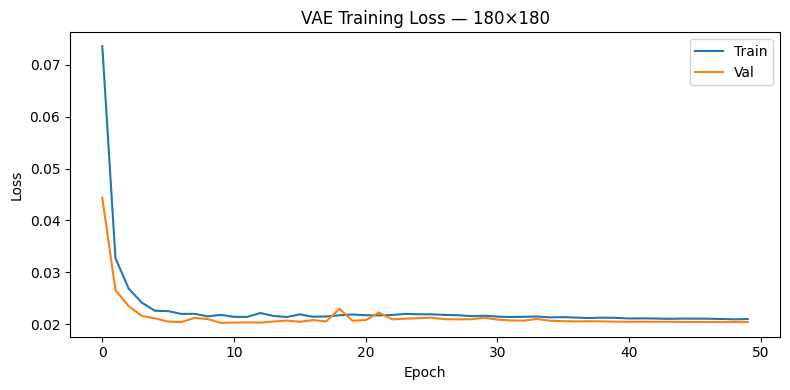

VAE training time: 209.7 min (12584 sec)


In [ ]:
# Cell 7: VAE Training — Stage 3: 180×180

import time
from torch.utils.data import WeightedRandomSampler

FORCE_RETRAIN_VAE = False

def gradient_loss(x_recon, x_real):
    dx_r = torch.abs(x_real[:, :, :, :-1] - x_real[:, :, :, 1:])
    dx_g = torch.abs(x_recon[:, :, :, :-1] - x_recon[:, :, :, 1:])
    dy_r = torch.abs(x_real[:, :, :-1, :] - x_real[:, :, 1:, :])
    dy_g = torch.abs(x_recon[:, :, :-1, :] - x_recon[:, :, 1:, :])
    return F.l1_loss(dx_g, dx_r) + F.l1_loss(dy_g, dy_r)

if FORCE_RETRAIN_VAE and os.path.exists(VAE_CKPT_PATH):
    os.remove(VAE_CKPT_PATH)
    print(f'Deleted existing checkpoint for retraining.')

if os.path.exists(VAE_CKPT_PATH):
    print(f'Loading existing VAE checkpoint from {VAE_CKPT_PATH}')
    vae.load_state_dict(torch.load(VAE_CKPT_PATH, map_location=DEVICE))
    print('VAE loaded — skip to Cell 8.')
else:
    print(f'Training VAE from scratch → will save to {VAE_CKPT_PATH}')

    counts  = train_ds.records['KL'].value_counts().to_dict()
    weights = [1.0 / counts[int(lbl)] for lbl in train_ds.records['KL']]
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    weighted_loader = DataLoader(train_ds, batch_size=VAE_BATCH_SIZE, sampler=sampler,
                                 num_workers=2, pin_memory=True)

    print('KL class weights:')
    for kl, cnt in sorted(counts.items()):
        print(f'  KL {kl}: {cnt} samples → weight {1/cnt:.5f}')

    optimizer = torch.optim.AdamW(vae.parameters(), lr=VAE_LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, VAE_EPOCHS)

    train_losses, val_losses = [], []
    vae_start = time.time()

    for epoch in range(1, VAE_EPOCHS + 1):
        kld_weight = min(VAE_KLD_WEIGHT, VAE_KLD_WEIGHT * (epoch / (VAE_EPOCHS * 0.5)))

        vae.train()
        epoch_loss = 0.0
        for imgs, _ in tqdm(weighted_loader, desc=f'VAE Epoch {epoch}/{VAE_EPOCHS}', leave=False):
            imgs = imgs.to(DEVICE)
            x_recon, mu, log_var = vae(imgs)

            recon_loss = F.mse_loss(x_recon, imgs, reduction='mean')
            kld_loss   = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
            grad_loss  = gradient_loss(x_recon, imgs)
            loss = recon_loss + kld_weight * kld_loss + GRAD_LOSS_WEIGHT * grad_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(weighted_loader))
        scheduler.step()

        vae.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(DEVICE)
                x_recon, mu, log_var = vae(imgs)
                recon_loss = F.mse_loss(x_recon, imgs, reduction='mean')
                kld_loss   = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
                grad_loss  = gradient_loss(x_recon, imgs)
                val_loss  += (recon_loss + kld_weight * kld_loss + GRAD_LOSS_WEIGHT * grad_loss).item()
        val_losses.append(val_loss / len(val_loader))

        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d} | Train: {train_losses[-1]:.4f} | '
                  f'Val: {val_losses[-1]:.4f} | KLD w: {kld_weight:.5f}')

    torch.save(vae.state_dict(), VAE_CKPT_PATH)
    print(f'\nVAE saved to {VAE_CKPT_PATH}')

    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses,   label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('VAE Training Loss — 180×180')
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'vae_loss_180.png'), dpi=120)   # ← _180 suffix
    plt.show()

    vae_elapsed = time.time() - vae_start
    print(f'VAE training time: {vae_elapsed/60:.1f} min ({vae_elapsed:.0f} sec)')

## Cell 8 — Visualise VAE Reconstructions

Check quality before moving to diffusion. If reconstructions look very blurry, the VAE needs more epochs or a higher `base_ch`.

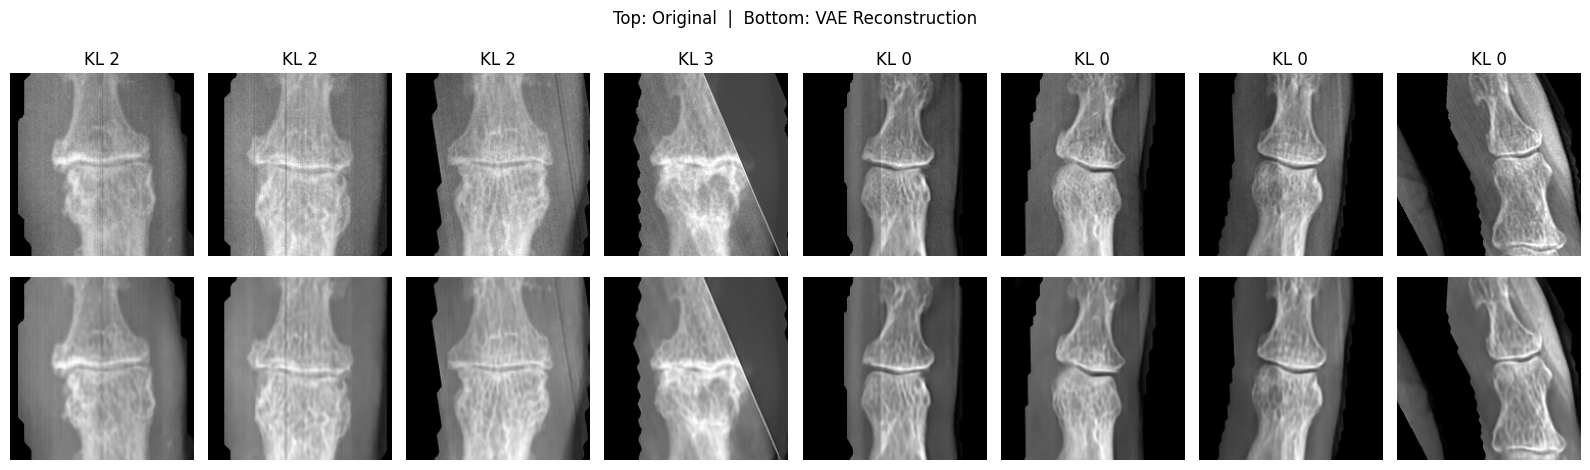

In [ ]:
vae.eval()
with torch.no_grad():
    imgs, labels = next(iter(val_loader))
    imgs = imgs[:8].to(DEVICE)
    recons, _, _ = vae(imgs)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Top: Original  |  Bottom: VAE Reconstruction', fontsize=12)
for i in range(8):
    orig = denorm(imgs[i].cpu()).squeeze().clamp(0, 1)
    rec  = denorm(recons[i].cpu()).squeeze().clamp(0, 1)
    axes[0][i].imshow(orig, cmap='gray'); axes[0][i].axis('off')
    axes[0][i].set_title(f'KL {labels[i].item()}')
    axes[1][i].imshow(rec,  cmap='gray'); axes[1][i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vae_reconstructions.png'), dpi=120)
plt.show()

## Cell 9 — DDPM Noise Schedule

We use a **linear noise schedule** (the original DDPM formulation). The LDM adds noise to the *latent* `z`, not the raw image.

Key quantities:
- `β_t` — how much noise to add at each step
- `ᾱ_t` — cumulative product of `(1 - β)`, used for the closed-form forward pass

DDPM schedule ready: T=1000 steps


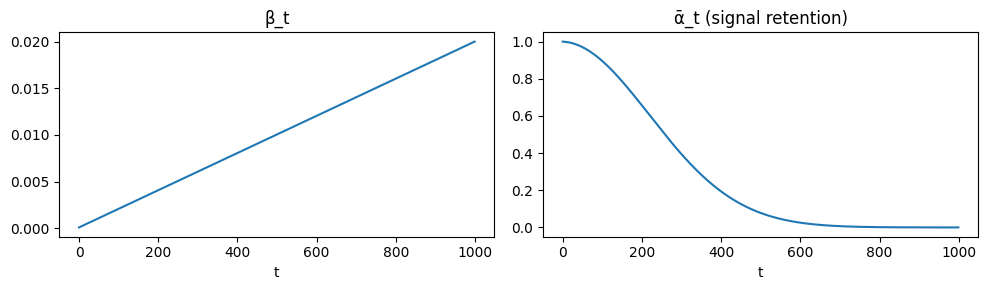

In [ ]:
class DDPMSchedule:
    """
    Linear beta schedule from DDPM (Ho et al., 2020).
    All tensors live on DEVICE.
    """
    def __init__(self, T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END):
        self.T = T
        self.betas      = torch.linspace(beta_start, beta_end, T).to(DEVICE)
        self.alphas     = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_ab    = torch.sqrt(self.alpha_bars)
        self.sqrt_1mab  = torch.sqrt(1.0 - self.alpha_bars)

    def q_sample(self, z0, t, noise=None):
        """Forward process: add noise to latent z0 at timestep t."""
        if noise is None:
            noise = torch.randn_like(z0)
        sqrt_ab  = self.sqrt_ab[t].view(-1, 1, 1, 1)
        sqrt_1mb = self.sqrt_1mab[t].view(-1, 1, 1, 1)
        return sqrt_ab * z0 + sqrt_1mb * noise, noise

    @torch.no_grad()
    def p_sample(self, model, z_t, t_int, kl_label, guidance_scale=1.0):
        """One reverse step: predict z_{t-1} from z_t."""
        t  = torch.tensor([t_int], device=DEVICE)
        kl = torch.tensor([kl_label], device=DEVICE)

        if guidance_scale > 1.0:
            eps_cond   = model(z_t, t, kl)
            kl_uncond  = torch.tensor([-1], device=DEVICE)
            eps_uncond = model(z_t, t, kl_uncond)
            eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        else:
            eps = model(z_t, t, kl)

        beta_t    = self.betas[t_int]
        alpha_t   = self.alphas[t_int]
        alpha_bar = self.alpha_bars[t_int]

        coef = beta_t / torch.sqrt(1.0 - alpha_bar)
        mean = (1.0 / torch.sqrt(alpha_t)) * (z_t - coef * eps)

        if t_int == 0:
            return mean
        noise = torch.randn_like(z_t)
        return mean + torch.sqrt(beta_t) * noise

    @torch.no_grad()
    def sample(self, model, shape, kl_label, guidance_scale=GUIDANCE_SCALE):
        """Full reverse diffusion: start from pure noise, return clean latent."""
        z = torch.randn(shape, device=DEVICE)
        for t in tqdm(reversed(range(self.T)), desc='Sampling', total=self.T, leave=False):
            z = self.p_sample(model, z, t, kl_label, guidance_scale)
        return z

    @torch.no_grad()
    def sample_from(self, model, z_init, t_start, kl_label, guidance_scale=GUIDANCE_SCALE):
        """
        Partial reverse diffusion: denoise from t_start down to 0,
        starting from an already-noised latent z_init.
        Used for progressive KL generation (KL0 → KL1 → ... → KL4).

        strength = t_start / T_STEPS controls how much the image changes:
          - 0.4 (t=400): subtle shift, preserves bone structure well
          - 0.5 (t=500): moderate — recommended starting point
          - 0.7 (t=700): aggressive, more creative freedom but may lose contour
        """
        z = z_init.clone()
        for t in tqdm(reversed(range(t_start)), desc=f'Sampling from t={t_start}',
                      total=t_start, leave=False):
            z = self.p_sample(model, z, t, kl_label, guidance_scale)
        return z


schedule = DDPMSchedule()
print(f'DDPM schedule ready: T={schedule.T} steps')

plt.figure(figsize=(10, 3))
plt.subplot(1,2,1); plt.plot(schedule.betas.cpu()); plt.title('β_t'); plt.xlabel('t')
plt.subplot(1,2,2); plt.plot(schedule.alpha_bars.cpu()); plt.title('ᾱ_t (signal retention)'); plt.xlabel('t')
plt.tight_layout(); plt.show()

## Cell 10 — UNet Denoiser with KL Conditioning

This is the core of the LDM. The UNet predicts the noise `ε` added to the latent at each timestep, conditioned on:
- `t` — the current timestep (encoded as a sinusoidal embedding)
- `kl` — the KL grade label (0–4), encoded as a learned embedding

**Classifier-free guidance (CFG):** during training, we randomly drop the KL label (10% of the time) and replace it with a null token. At inference, we run the model twice (with and without the label) and interpolate — this sharpens KL-grade conditioning.

In [ ]:
# Cell 10a: UNet helper modules

def get_groups(ch):
    for g in [8, 4, 2, 1]:
        if ch % g == 0:
            return g
    return 1

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.GroupNorm(get_groups(ch), ch),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.GroupNorm(get_groups(ch), ch),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
        )
    def forward(self, x):
        return x + self.net(x)

class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.norm1    = nn.GroupNorm(get_groups(in_ch), in_ch)
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(get_groups(out_ch), out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch * 2)
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.emb_proj(F.silu(emb)).chunk(2, dim=-1)
        h = self.norm2(h) * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = self.conv2(F.silu(h))
        return h + self.skip(x)

class SelfAttention(nn.Module):
    def __init__(self, ch, n_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(get_groups(ch), ch)
        self.attn = nn.MultiheadAttention(ch, n_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        h = rearrange(h, 'b c h w -> b (h w) c')
        h, _ = self.attn(h, h, h)
        h = rearrange(h, 'b (h w) c -> b c h w', h=H, w=W)
        return x + h

def sinusoidal_embedding(t, dim):
    half  = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
    )
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


# Cell 10b: Conditional UNet

class ConditionalUNet(nn.Module):
    def __init__(self, latent_ch=LATENT_CH, base_ch=UNET_BASE_CH, emb_dim=256,
                 num_kl=NUM_KL_CLASSES, cfg_dropout=0.10):
        super().__init__()
        self.cfg_dropout = cfg_dropout

        self.time_mlp = nn.Sequential(
            nn.Linear(base_ch, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.kl_emb = nn.Embedding(num_kl + 1, emb_dim, padding_idx=num_kl)

        # Encoder — two blocks per level
        # At 180×180: latent is 22×22; after one MaxPool → 11×11
        self.enc1a = UNetBlock(latent_ch,  base_ch,   emb_dim)   # 22×22
        self.enc1b = UNetBlock(base_ch,    base_ch,   emb_dim)   # 22×22

        self.enc2a = UNetBlock(base_ch,    base_ch*2, emb_dim)   # 11×11 (after down)
        self.enc2b = UNetBlock(base_ch*2,  base_ch*2, emb_dim)   # 11×11

        # Bottleneck — attention at 11×11 (121 tokens, efficient on T4)
        self.mid1 = UNetBlock(base_ch*2, base_ch*2, emb_dim)
        self.attn  = SelfAttention(base_ch*2)
        self.mid2 = UNetBlock(base_ch*2, base_ch*2, emb_dim)

        # Decoder — up(11×11)→22×22, concat with enc1 skip (22×22)
        self.dec2a = UNetBlock(base_ch*2 + base_ch, base_ch,   emb_dim)
        self.dec2b = UNetBlock(base_ch,             base_ch,   emb_dim)
        self.dec1a = UNetBlock(base_ch,             base_ch,   emb_dim)
        self.dec1b = UNetBlock(base_ch,             base_ch,   emb_dim)

        self.out = nn.Sequential(
            nn.GroupNorm(get_groups(base_ch), base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch, latent_ch, 3, padding=1),
        )

        self.down = nn.MaxPool2d(2)
        self.up   = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, z, t, kl_label):
        t_emb = sinusoidal_embedding(t, self.time_mlp[0].in_features)
        t_emb = self.time_mlp(t_emb)

        kl_idx = kl_label.clone()
        kl_idx[kl_idx < 0] = NUM_KL_CLASSES
        if self.training:
            drop = torch.rand(kl_idx.shape, device=kl_idx.device) < self.cfg_dropout
            kl_idx[drop] = NUM_KL_CLASSES
        kl_emb = self.kl_emb(kl_idx)
        emb = t_emb + kl_emb

        # Encoder
        e1 = self.enc1b(self.enc1a(z, emb), emb)              # (B, base_ch,   22×22)
        e2 = self.enc2b(self.enc2a(self.down(e1), emb), emb)  # (B, base_ch*2, 11×11)

        # Bottleneck
        m = self.mid1(e2, emb)
        m = self.attn(m)
        m = self.mid2(m, emb)                                  # (B, base_ch*2, 11×11)

        # Decoder — up(m) is 22×22, concat with e1 (22×22)
        d = self.dec2a(torch.cat([self.up(m), e1], dim=1), emb)
        d = self.dec2b(d, emb)
        d = self.dec1a(d, emb)
        d = self.dec1b(d, emb)

        return self.out(d)


unet = ConditionalUNet().to(DEVICE)
total_params = sum(p.numel() for p in unet.parameters())
print(f'UNet parameters: {total_params:,}')

dummy_z  = torch.randn(4, LATENT_CH, LATENT_SIZE, LATENT_SIZE, device=DEVICE)
dummy_t  = torch.randint(0, T_STEPS, (4,), device=DEVICE)
dummy_kl = torch.tensor([0, 1, 3, 4], device=DEVICE)
out = unet(dummy_z, dummy_t, dummy_kl)
print(f'UNet output shape: {out.shape}  (expected: [4, {LATENT_CH}, {LATENT_SIZE}, {LATENT_SIZE}])')

UNet parameters: 4,567,512
UNet output shape: torch.Size([4, 8, 22, 22])  (expected: [4, 8, 22, 22])


## Cell 11 — LDM Training Loop

With the VAE frozen, we train the UNet to denoise in latent space.

**Training algorithm (per batch):**
1. Encode images → latents `z0 = VAE.encode(x)`
2. Sample random timestep `t`
3. Add noise: `z_t = √ᾱ_t · z0 + √(1-ᾱ_t) · ε`
4. UNet predicts noise: `ε̂ = UNet(z_t, t, kl_label)`
5. Loss: `MSE(ε̂, ε)`

LDM KL class weights:
  KL 0: 5947 samples → weight 0.00017
  KL 1: 1220 samples → weight 0.00082
  KL 2: 1770 samples → weight 0.00056
  KL 3: 144 samples → weight 0.00694
  KL 4: 118 samples → weight 0.00847
Training LDM from scratch → will save to /content/drive/MyDrive/CV-Project/ldm_checkpoint_180.pth


Epoch  10 | Train: 0.2493 | Val: 0.2554


Epoch  20 | Train: 0.2397 | Val: 0.2566


Epoch  30 | Train: 0.2418 | Val: 0.2461


Epoch  40 | Train: 0.2444 | Val: 0.2482


...

Epoch 110 | Train: 0.2425 | Val: 0.2510


Epoch 120 | Train: 0.2339 | Val: 0.2388


Epoch 130 | Train: 0.2349 | Val: 0.2406


Epoch 140 | Train: 0.2325 | Val: 0.2554


Epoch 150 | Train: 0.2332 | Val: 0.2491

Training done. Best val loss: 0.2256
LDM training time: 150.7 min (9043 sec)


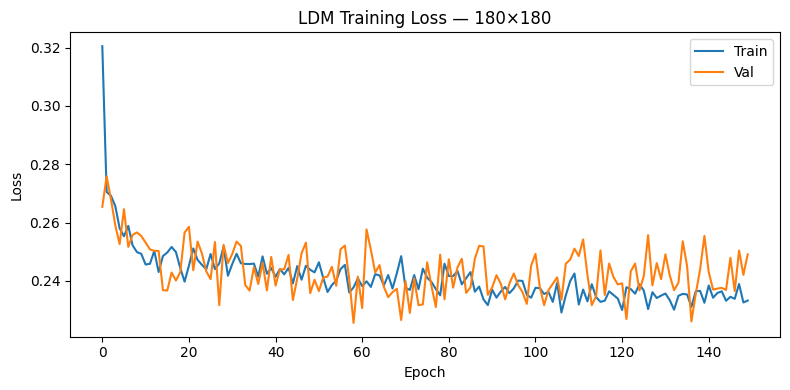

In [ ]:
# Cell 11: LDM Training Loop — Stage 3: 180×180

import time
from torch.utils.data import WeightedRandomSampler

FORCE_RETRAIN_LDM = False

# Freeze VAE
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

# ── Weighted sampler ──────────────────────────────────────────────────────────
counts  = train_ds.records['KL'].value_counts().to_dict()
weights = [1.0 / counts[int(lbl)] for lbl in train_ds.records['KL']]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

ldm_train_loader = DataLoader(train_ds, batch_size=LDM_BATCH_SIZE, sampler=sampler,
                               num_workers=2, pin_memory=True)
ldm_val_loader   = DataLoader(val_ds, batch_size=LDM_BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)

print('LDM KL class weights:')
for kl, cnt in sorted(counts.items()):
    print(f'  KL {kl}: {cnt} samples → weight {1/cnt:.5f}')

# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(unet.parameters(), lr=LDM_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, LDM_EPOCHS)

# ── Force retrain ─────────────────────────────────────────────────────────────
if FORCE_RETRAIN_LDM and os.path.exists(LDM_CKPT_PATH):
    os.remove(LDM_CKPT_PATH)
    print(f'Deleted existing LDM checkpoint for retraining.')

# ── Resume if checkpoint exists ───────────────────────────────────────────────
start_epoch = 1
if os.path.exists(LDM_CKPT_PATH):
    print(f'Resuming from {LDM_CKPT_PATH}')
    ckpt = torch.load(LDM_CKPT_PATH, map_location=DEVICE)
    unet.load_state_dict(ckpt['model'])
    if 'optimizer' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt.get('epoch', 1) + 1
    for _ in range(start_epoch - 1):
        scheduler.step()
    print(f'Resuming from epoch {start_epoch}')

    if start_epoch > LDM_EPOCHS:
        print(f'Training already complete ({LDM_EPOCHS} epochs). Skipping.')
        unet.eval()
else:
    print(f'Training LDM from scratch → will save to {LDM_CKPT_PATH}')

if start_epoch <= LDM_EPOCHS:
    train_losses, val_losses = [], []
    best_val  = float('inf')
    ldm_start = time.time()

    for epoch in range(start_epoch, LDM_EPOCHS + 1):

        # ── Training ──────────────────────────────────────────────────────────
        unet.train()
        epoch_loss = 0.0

        for imgs, kl_labels in tqdm(ldm_train_loader, desc=f'LDM Epoch {epoch}/{LDM_EPOCHS}', leave=False):
            imgs      = imgs.to(DEVICE)
            kl_labels = kl_labels.to(DEVICE)

            with torch.no_grad():
                mu, log_var = vae.encode(imgs)
                z0 = vae.reparameterise(mu, log_var)

            t          = torch.randint(0, T_STEPS, (imgs.shape[0],), device=DEVICE)
            z_t, noise = schedule.q_sample(z0, t)
            noise_pred = unet(z_t, t, kl_labels)
            loss       = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(ldm_train_loader))
        scheduler.step()

        # ── Validation ────────────────────────────────────────────────────────
        unet.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, kl_labels in ldm_val_loader:
                imgs      = imgs.to(DEVICE)
                kl_labels = kl_labels.to(DEVICE)
                mu, log_var = vae.encode(imgs)
                z0          = vae.reparameterise(mu, log_var)
                t           = torch.randint(0, T_STEPS, (imgs.shape[0],), device=DEVICE)
                z_t, noise  = schedule.q_sample(z0, t)
                noise_pred  = unet(z_t, t, kl_labels)
                val_loss   += F.mse_loss(noise_pred, noise).item()
        val_losses.append(val_loss / len(ldm_val_loader))

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}')

        if val_losses[-1] < best_val:
            best_val = val_losses[-1]
            torch.save({
                'model':     unet.state_dict(),
                'optimizer': optimizer.state_dict(),
                'epoch':     epoch
            }, LDM_CKPT_PATH)

    ldm_elapsed = time.time() - ldm_start
    print(f'\nTraining done. Best val loss: {best_val:.4f}')
    print(f'LDM training time: {ldm_elapsed/60:.1f} min ({ldm_elapsed:.0f} sec)')

    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses,   label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('LDM Training Loss — 180×180')
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'ldm_loss_180.png'), dpi=120)
    plt.show()

## Cell 12 — Generate Synthetic Images

Load the best checkpoint and generate images for any KL grade. This is the core output of Stage 2 — we focus on **KL 0, KL 1, KL 2, KL 3 and KL 4**.

The `guidance_scale` controls how strongly the model follows the KL conditioning:
- `1.0` = no guidance (unconditional)
- `3.0–5.0` = recommended range
- `>7.0` = very strong, but may reduce diversity

Loaded checkpoint from epoch 59

Generating KL 0, 1, 2 from pure noise...



Generating KL 3, 4 from real KL 0/1/2 images...
[val] Loaded 1939 images
  KL distribution: {0: np.int64(1269), 1: np.int64(288), 2: np.int64(382)}
  Source pool: 1939 real KL [0, 1, 2] images


[val] Loaded 1939 images
  KL distribution: {0: np.int64(1269), 1: np.int64(288), 2: np.int64(382)}
  Source pool: 1939 real KL [0, 1, 2] images


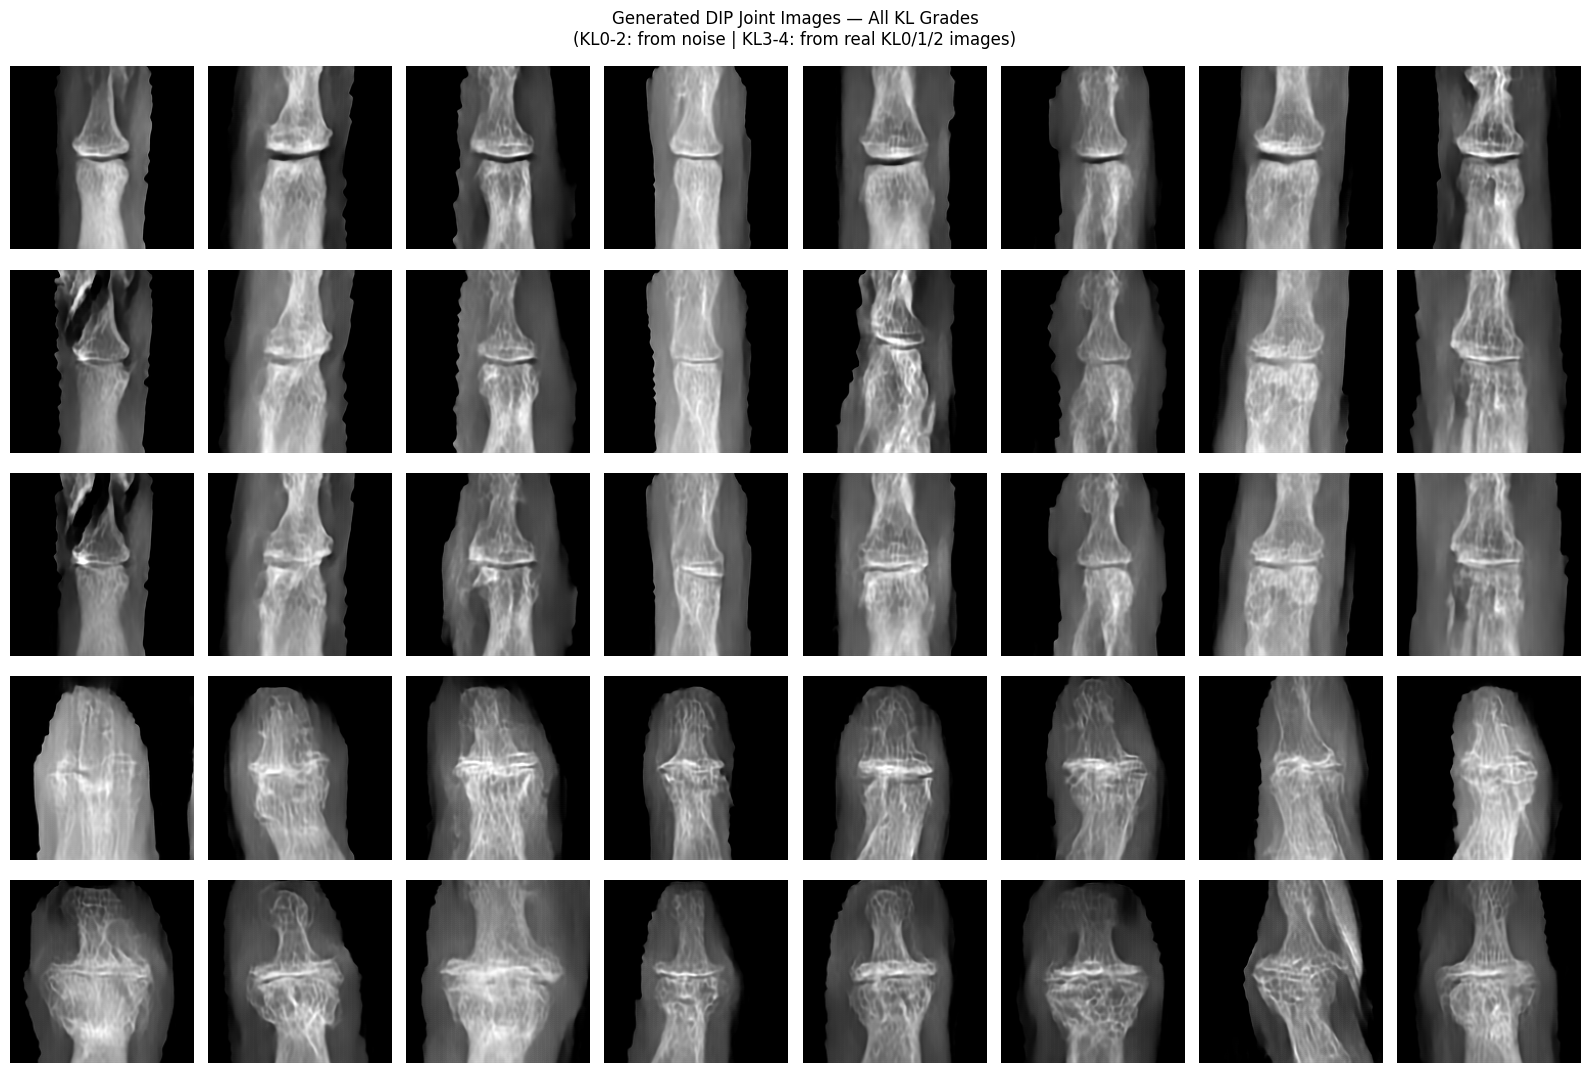

Saved to /content/drive/MyDrive/CV-Project/generated_images


In [ ]:
# Cell 12: Generation — KL0/1/2 from noise, KL3/4 from real KL0/1/2 images

import sys

class _SuppressOutput:
    def write(self, *args, **kwargs): pass
    def flush(self, *args, **kwargs): pass

GUIDANCE_PER_GRADE = {
    0: 4.0,
    1: 4.0,
    2: 4.0,
    3: 6.0,
    4: 6.0,
}

# Strength for KL3/4 generation from real sources.
# 0.6 = add 60% noise to the real latent, giving the model enough freedom
# to add disease features while preserving underlying bone anatomy.
KL34_STRENGTH    = 0.6
SOURCE_KL_GRADES = [0, 1, 2]   # which real grades to use as source images


def generate_from_noise(kl_grade, n=8):
    """Generate KL0/1/2 images from pure random noise."""
    vae.eval(); unet.eval()
    images       = []
    latent_shape = (1, LATENT_CH, LATENT_SIZE, LATENT_SIZE)
    gs           = GUIDANCE_PER_GRADE[kl_grade]

    with torch.no_grad():
        for i in tqdm(range(n), desc=f'Generating KL {kl_grade} from noise', leave=False):
            set_seed(GENERATION_SEED + i)
            _stderr, sys.stderr = sys.stderr, _SuppressOutput()
            try:
                z = schedule.sample(unet, latent_shape,
                                    kl_label=kl_grade,
                                    guidance_scale=gs)
            finally:
                sys.stderr = _stderr
            img    = vae.decode(z)
            img    = denorm(img.cpu()).squeeze().clamp(0, 1)
            img_np = (img.numpy() * 255).astype(np.uint8)
            images.append(Image.fromarray(img_np))
    return images


def generate_kl34_from_real(kl_target, n=8, strength=KL34_STRENGTH):
    """
    Generate KL3/4 images by encoding real KL0/1/2 images and denoising
    toward the target grade. Preserves real bone anatomy.
    """
    vae.eval(); unet.eval()
    images  = []
    gs      = GUIDANCE_PER_GRADE[kl_target]
    t_start = int(T_STEPS * strength)

    # Use val split so source images were not seen during training
    source_ds = DIPJointDataset(MANIFEST_PATH, split='val',
                                transform=val_transform,
                                kl_grades=SOURCE_KL_GRADES)
    print(f'  Source pool: {len(source_ds)} real KL {SOURCE_KL_GRADES} images')

    with torch.no_grad():
        for i in tqdm(range(n), desc=f'Generating KL {kl_target} from real sources', leave=False):
            set_seed(GENERATION_SEED + i)

            # Cycle through real source images
            src_img, src_kl = source_ds[i % len(source_ds)]
            src_img = src_img.unsqueeze(0).to(DEVICE)

            # Encode real image to latent
            mu, log_var = vae.encode(src_img)
            z0 = vae.reparameterise(mu, log_var)

            # Add noise at t_start
            t_tensor   = torch.tensor([t_start], device=DEVICE)
            z_noisy, _ = schedule.q_sample(z0, t_tensor)

            # Denoise toward target KL grade
            _stderr, sys.stderr = sys.stderr, _SuppressOutput()
            try:
                z = schedule.sample_from(unet, z_noisy,
                                         t_start=t_start,
                                         kl_label=kl_target,
                                         guidance_scale=gs)
            finally:
                sys.stderr = _stderr

            img    = vae.decode(z)
            img    = denorm(img.cpu()).squeeze().clamp(0, 1)
            img_np = (img.numpy() * 255).astype(np.uint8)
            images.append(Image.fromarray(img_np))
    return images


# ── Load checkpoint ───────────────────────────────────────────────────────────
ckpt = torch.load(LDM_CKPT_PATH, map_location=DEVICE)
unet.load_state_dict(ckpt['model'])
unet.eval(); vae.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]}')

# ── Generate all grades ───────────────────────────────────────────────────────
print('\nGenerating KL 0, 1, 2 from pure noise...')
all_images = {}
for kl in [0, 1, 2]:
    all_images[kl] = generate_from_noise(kl, n=8)

print('\nGenerating KL 3, 4 from real KL 0/1/2 images...')
for kl in [3, 4]:
    all_images[kl] = generate_kl34_from_real(kl, n=8, strength=KL34_STRENGTH)

# ── Display ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 8, figsize=(16, 11))
fig.suptitle('Generated DIP Joint Images — All KL Grades\n'
             '(KL0-2: from noise | KL3-4: from real KL0/1/2 images)', fontsize=12)
for row, kl in enumerate(range(5)):
    method = 'noise' if kl <= 2 else f'real src (s={KL34_STRENGTH})'
    for col, img in enumerate(all_images[kl]):
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(f'KL {kl}\n(gs={GUIDANCE_PER_GRADE[kl]}, {method})',
                            fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'generated_all_kl.png'), dpi=150)
plt.show()
print(f'Saved to {OUTPUT_DIR}')

## Cell 13 — Side-by-Side Comparison: Real vs. Generated

Compare generated images against real KL 3/4 samples from the validation set.

[val] Loaded 1269 images
  KL distribution: {0: np.int64(1269)}
[val] Loaded 288 images
  KL distribution: {1: np.int64(288)}
[val] Loaded 382 images
  KL distribution: {2: np.int64(382)}
[val] Loaded 29 images
  KL distribution: {3: np.int64(29)}
[val] Loaded 25 images
  KL distribution: {4: np.int64(25)}


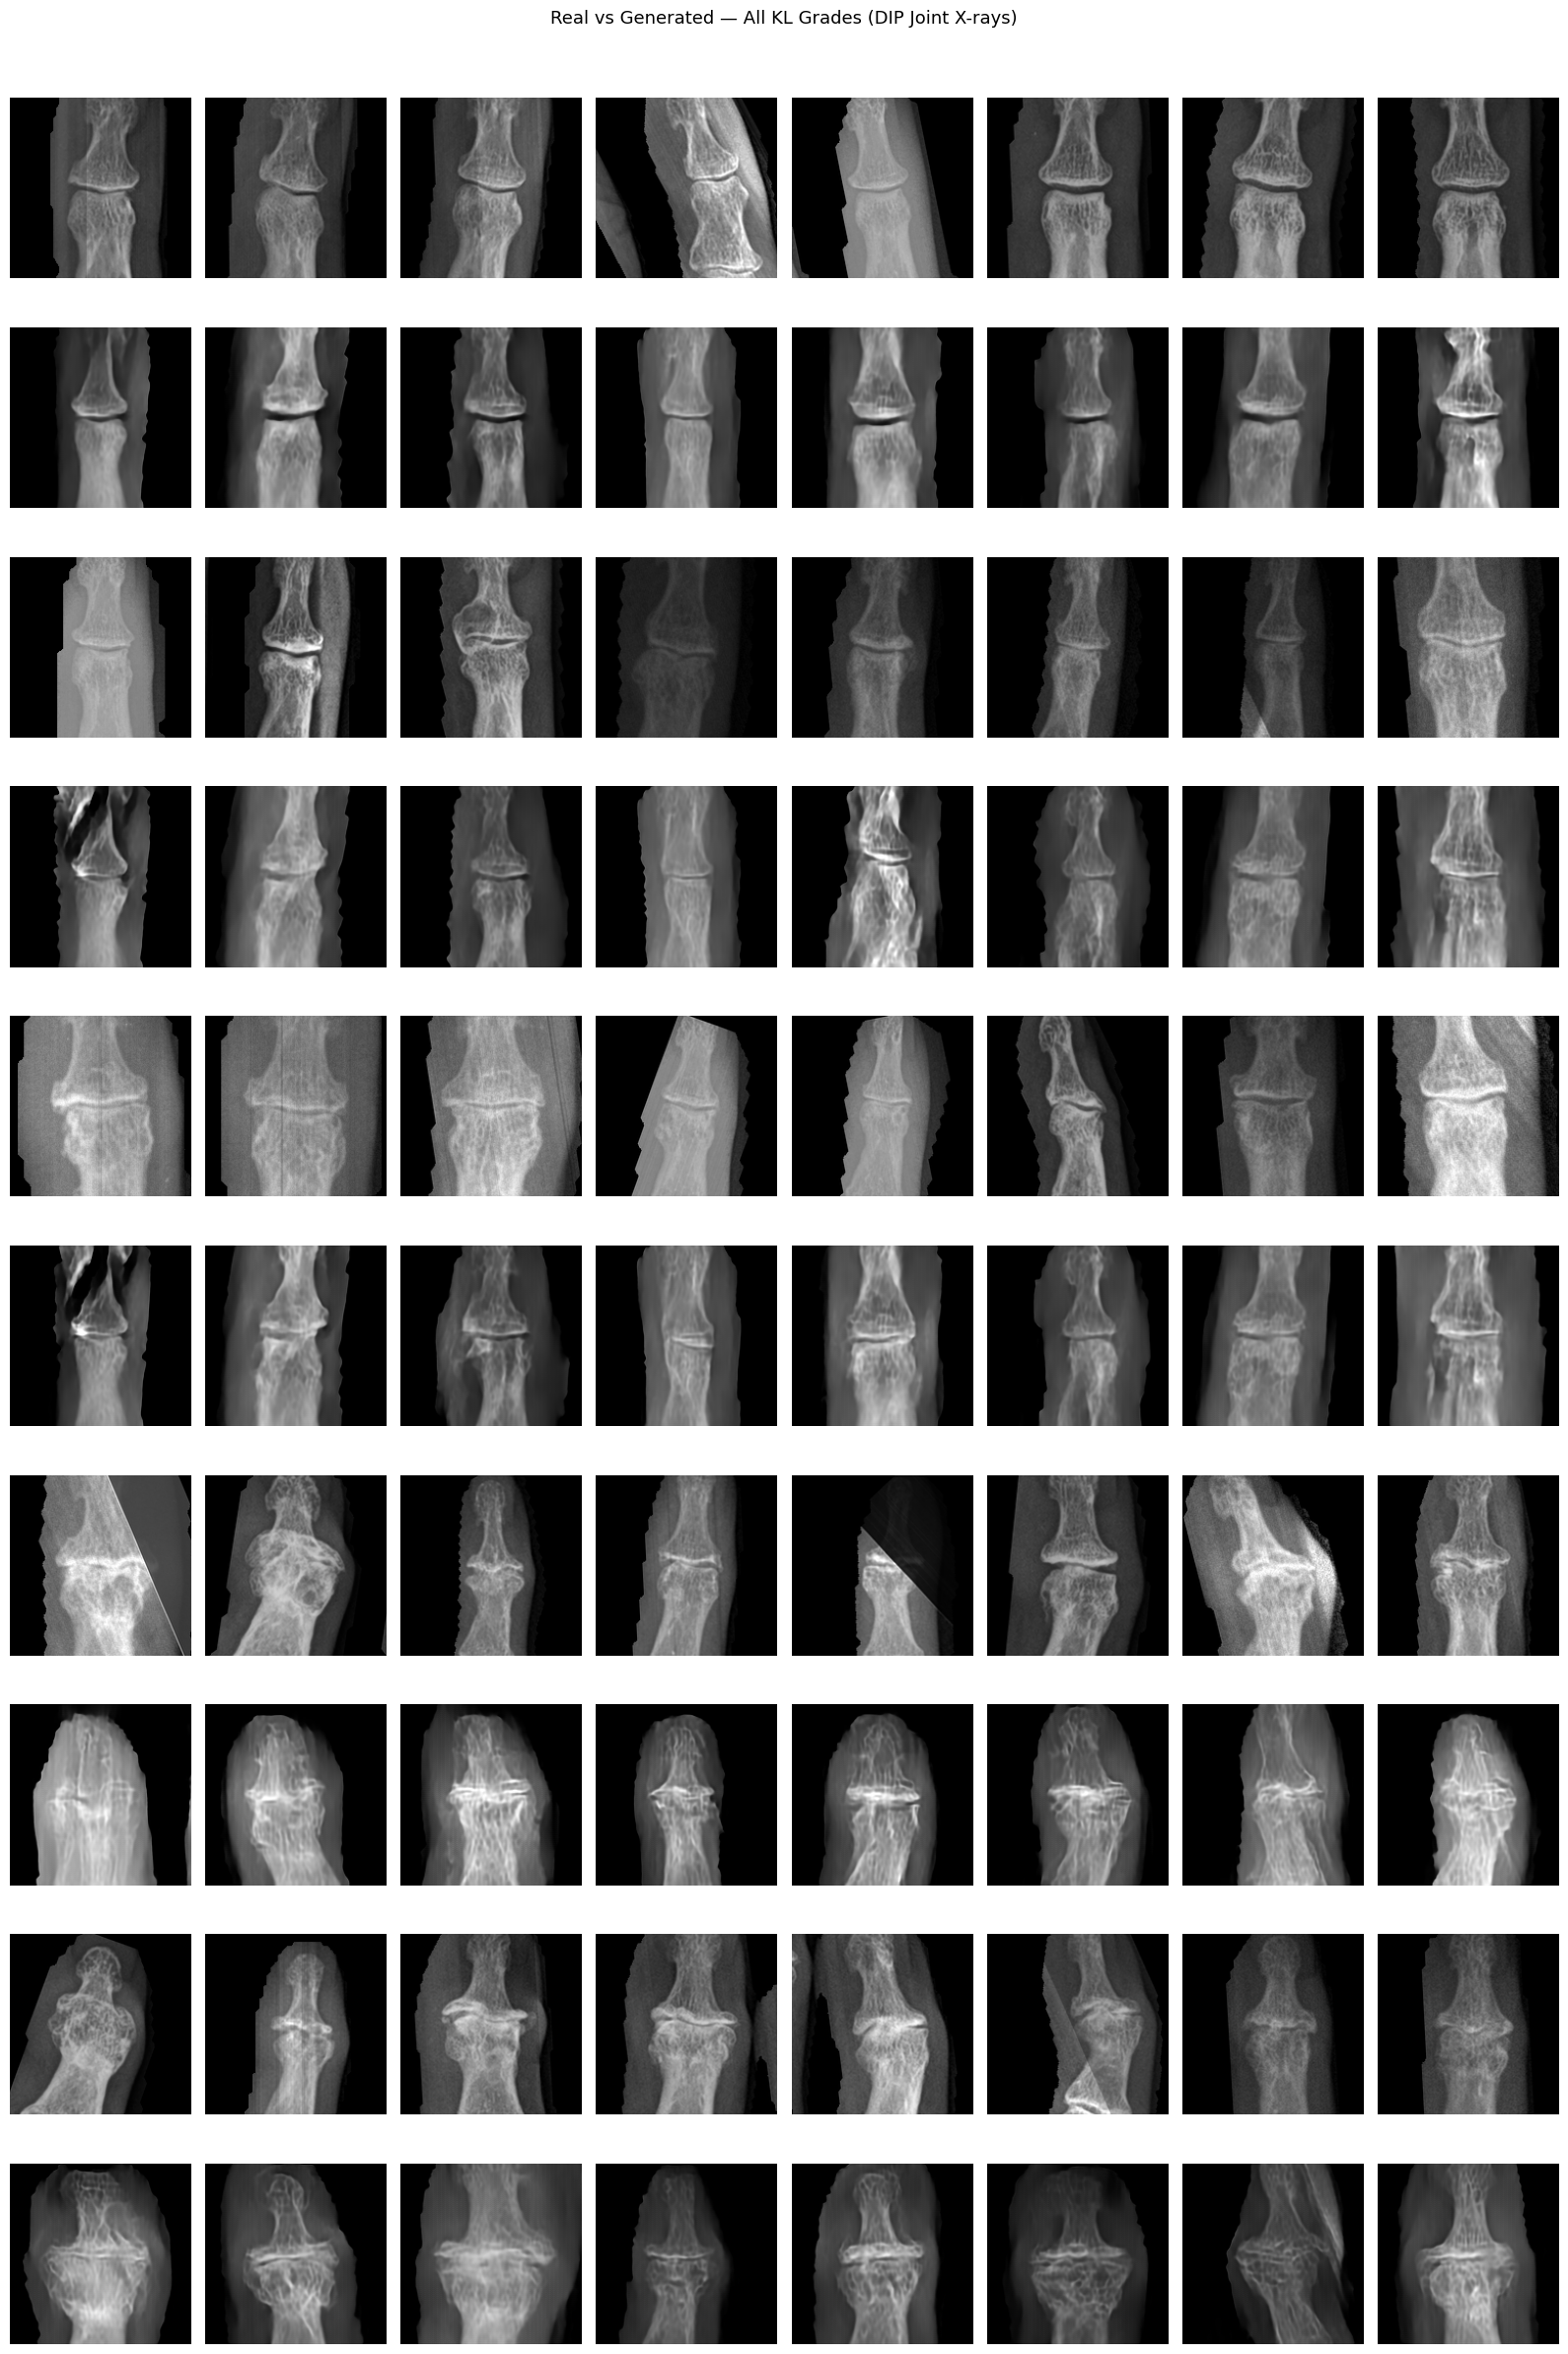

In [ ]:
# Real vs Generated comparison for all KL grades
all_kl_real = {}
for kl in [0, 1, 2, 3, 4]:
    ds = DIPJointDataset(MANIFEST_PATH, split='val', transform=val_transform, kl_grades=[kl])
    all_kl_real[kl] = [denorm(ds[i][0]).squeeze().clamp(0, 1).numpy()
                       for i in range(min(8, len(ds)))]

fig, axes = plt.subplots(10, 8, figsize=(16, 24))

for row_offset, kl in enumerate([0, 1, 2, 3, 4]):
    real_row = row_offset * 2
    gen_row  = row_offset * 2 + 1

    for col in range(8):
        ax_r = axes[real_row][col]
        if col < len(all_kl_real[kl]):
            ax_r.imshow(all_kl_real[kl][col], cmap='gray', vmin=0, vmax=1)
        ax_r.axis('off')
        if col == 0:
            ax_r.set_ylabel(f'Real KL {kl}', fontsize=9, labelpad=45, rotation=0, va='center')

        ax_g = axes[gen_row][col]
        if col < len(all_images[kl]):
            ax_g.imshow(np.array(all_images[kl][col]) / 255, cmap='gray', vmin=0, vmax=1)
        ax_g.axis('off')
        if col == 0:
            ax_g.set_ylabel(f'Gen KL {kl}', fontsize=9, labelpad=45, rotation=0, va='center')

plt.suptitle('Real vs Generated — All KL Grades (DIP Joint X-rays)', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'real_vs_generated_all_kl.png'), dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 — Save Generated Images to Drive

Save the generated images as individual PNG files for use in Zulal's FID evaluation pipeline.

In [ ]:
# Cell 14: Generate and save 300 images per KL grade — Stage 3: 180×180

import json, csv, sys
from datetime import datetime

GUIDANCE_PER_GRADE = {0: 4.0, 1: 4.0, 2: 4.0, 3: 6.0, 4: 6.0}
KL34_STRENGTH      = 0.6
SOURCE_KL_GRADES   = [0, 1, 2]
N_PER_GRADE        = 300

DIFFUSION_OUT      = '/content/drive/MyDrive/CV-Project/models/diffusion_outputs'
imgs_180_dir       = os.path.join(DIFFUSION_OUT, 'images_180')
imgs_by_kl_180_dir = os.path.join(DIFFUSION_OUT, 'images_by_kl_180')

for kl in [0, 1, 2, 3, 4]:
    os.makedirs(imgs_180_dir, exist_ok=True)
    os.makedirs(os.path.join(imgs_by_kl_180_dir, f'kl{kl}'), exist_ok=True)

print('Output folders ready — Stage 3: 180×180')
print(f'Method: KL0/1/2 from noise | KL3/4 from real KL{SOURCE_KL_GRADES} (strength={KL34_STRENGTH})')
print(f'  {imgs_180_dir}')
print(f'  {imgs_by_kl_180_dir}/kl{{0-4}}/')

# ── Generate KL 0, 1, 2 from noise ───────────────────────────────────────────
all_images = {}

print('\nGenerating KL 0, 1, 2 from noise...')
for kl in [0, 1, 2]:
    print(f'  KL {kl}...')
    all_images[kl] = generate_from_noise(kl, n=N_PER_GRADE)

# ── Generate KL 3, 4 from real KL 0/1/2 images (train split) ─────────────────
print('\nGenerating KL 3, 4 from real KL 0/1/2 images...')
for kl in [3, 4]:
    print(f'  KL {kl}...')

    source_ds = DIPJointDataset(MANIFEST_PATH, split='train',
                                transform=val_transform,
                                kl_grades=SOURCE_KL_GRADES)
    images  = []
    gs      = GUIDANCE_PER_GRADE[kl]
    t_start = int(T_STEPS * KL34_STRENGTH)

    vae.eval(); unet.eval()
    with torch.no_grad():
        for i in tqdm(range(N_PER_GRADE), desc=f'KL {kl} from real sources'):
            set_seed(GENERATION_SEED + i)
            src_img, _ = source_ds[i % len(source_ds)]
            src_img    = src_img.unsqueeze(0).to(DEVICE)

            mu, log_var = vae.encode(src_img)
            z0          = vae.reparameterise(mu, log_var)
            t_tensor    = torch.tensor([t_start], device=DEVICE)
            z_noisy, _  = schedule.q_sample(z0, t_tensor)

            _stderr, sys.stderr = sys.stderr, _SuppressOutput()
            try:
                z = schedule.sample_from(unet, z_noisy,
                                         t_start=t_start,
                                         kl_label=kl,
                                         guidance_scale=gs)
            finally:
                sys.stderr = _stderr

            img    = vae.decode(z)
            img    = denorm(img.cpu()).squeeze().clamp(0, 1)
            img_np = (img.numpy() * 255).astype(np.uint8)
            images.append(Image.fromarray(img_np))
    all_images[kl] = images

# ── Save ──────────────────────────────────────────────────────────────────────
manifest_rows = []
for kl_grade in [0, 1, 2, 3, 4]:
    for i, img in enumerate(all_images[kl_grade]):
        filename = f'diff180_kl{kl_grade}_{i+1:04d}.png'
        img.save(os.path.join(imgs_180_dir, filename))
        img.save(os.path.join(imgs_by_kl_180_dir, f'kl{kl_grade}', filename))
        src = 'diffusion_noise' if kl_grade <= 2 else 'diffusion_from_real'
        manifest_rows.append({'filename': filename, 'KL': kl_grade,
                               'joint_type': 'DIP', 'source': src,
                               'resolution': '180x180'})
    print(f'  KL {kl_grade}: {len(all_images[kl_grade])} images saved.')

print(f'\nTotal saved: {len(manifest_rows)} images.')

manifest_path = os.path.join(DIFFUSION_OUT, 'synthetic_manifest_180.csv')
with open(manifest_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['filename', 'KL', 'joint_type', 'source', 'resolution'])
    writer.writeheader(); writer.writerows(manifest_rows)
print(f'Manifest saved: {manifest_path}')

best_epoch = ckpt.get('epoch', 0)
training_log = {
    'model': 'LDM (VAE + Conditional UNet)',
    'stage': 'Stage 3 — 180×180',
    'date':  datetime.today().strftime('%Y-%m-%d'),
    'config': {
        'img_size': IMG_SIZE, 'latent_ch': LATENT_CH, 'latent_size': LATENT_SIZE,
        'vae_epochs': VAE_EPOCHS, 'vae_kld_weight': VAE_KLD_WEIGHT,
        'ldm_epochs': LDM_EPOCHS, 'ldm_lr': LDM_LR,
        't_steps': T_STEPS, 'guidance_per_grade': GUIDANCE_PER_GRADE,
        'kl34_strength': KL34_STRENGTH, 'source_kl_grades': SOURCE_KL_GRADES,
        'generation_method': 'noise for KL0-2, real-image-conditioned for KL3-4',
    },
    'results': {
        'ldm_best_epoch': best_epoch,
        'n_generated_per_grade': N_PER_GRADE,
        'total_images': N_PER_GRADE * 5,
        'resolution': '180x180',
    },
    'notes': 'Stage 3: full 180x180 resolution. KL3/4 from real KL0/1/2 (strength=0.6).'
}

log_path = os.path.join(DIFFUSION_OUT, 'training_log_180.json')
with open(log_path, 'w') as f:
    json.dump(training_log, f, indent=2)
print(f'Training log saved: {log_path}')

Output folders ready — Stage 3: 180×180
Method: KL0/1/2 from noise | KL3/4 from real KL[0, 1, 2] (strength=0.6)
  /content/drive/MyDrive/CV-Project/models/diffusion_outputs/images_180
  /content/drive/MyDrive/CV-Project/models/diffusion_outputs/images_by_kl_180/kl{0-4}/

Generating KL 0, 1, 2 from noise...
  KL 0...


  KL 1...


  KL 2...



Generating KL 3, 4 from real KL 0/1/2 images...
  KL 3...
[train] Loaded 8937 images
  KL distribution: {0: np.int64(5947), 1: np.int64(1220), 2: np.int64(1770)}


KL 3 from real sources: 100%|██████████| 300/300 [43:23<00:00,  8.68s/it]


  KL 4...
[train] Loaded 8937 images
  KL distribution: {0: np.int64(5947), 1: np.int64(1220), 2: np.int64(1770)}


KL 4 from real sources: 100%|██████████| 300/300 [43:25<00:00,  8.68s/it]


  KL 0: 300 images saved.
  KL 1: 300 images saved.
  KL 2: 300 images saved.
  KL 3: 300 images saved.
  KL 4: 300 images saved.

Total saved: 1500 images.
Manifest saved: /content/drive/MyDrive/CV-Project/models/diffusion_outputs/synthetic_manifest_180.csv
Training log saved: /content/drive/MyDrive/CV-Project/models/diffusion_outputs/training_log_180.json
